In [2]:
#import pandas
import pandas as pd

#import matplot
import matplotlib.pyplot as plt

In [3]:
#panda display settings
pd.set_option('display.notebook_repr_html', True) #shows panda dataframes as HTML tables
pd.set_option('display.precision', 2) #sets precision to 2 decimal places
pd.set_option('display.float_format', '{:.2f}'.format) #sets floating point number format to 2 decimal places with python string formatting

In [4]:
#imports the specific sheet of the file and skips needed rows
eg = pd.read_excel('Education_API_SE.XPD.TOTL.GD.ZS_DS2_en_excel_v2_560.xls', sheet_name ='Data', skiprows = 3) #Education Spending as Percent of GDP
hg = pd.read_excel('Health_API_SH.XPD.CHEX.GD.ZS_DS2_en_excel_v2_15.xls', sheet_name ='Data', skiprows = 3) #Healthcare Spending as Percent of GDP
mg = pd.read_excel('SIPRI-Milex-data-1948-2023.xlsx', sheet_name = 'Share of GDP', skiprows = 5) #Military Spending as Percent of GDP
hpc = pd.read_excel('API_SH.XPD.CHEX.PC.CD_DS2_en_excel_v2_76304.xls', sheet_name ='Data', skiprows = 3) #Healthcare Spending Per Capita
mpc = pd.read_excel('SIPRI-Milex-data-1948-2023.xlsx', sheet_name ='Per capita', skiprows = 6) #Military Spending Per Capita
ms = pd.read_excel('SIPRI-Milex-data-1948-2023.xlsx', sheet_name ='Constant (2022) US$', skiprows = 5) #Military Spending
gdpt = pd.read_excel('API_NY.GDP.MKTP.CD_DS2_en_excel_v2_76262.xls', sheet_name = 'Data', skiprows = 3) #GDP
gdpc = pd.read_excel('API_NY.GDP.PCAP.CD_DS2_en_excel_v2_114300.xls', sheet_name = 'Data', skiprows = 3) #GDP Per Capita
pop = pd.read_excel('API_SP.POP.TOTL_DS2_en_excel_v2_76243.xls', sheet_name = 'Data', skiprows = 3) #Population

In [5]:
# Makes necessary columns numeric
numeric_cols = ms.columns.drop(['Country', 'Notes'], errors='ignore')
ms[numeric_cols] = ms[numeric_cols].apply(pd.to_numeric, errors='coerce')


# Data organized by country and summed up
military_total = ms.groupby('Country').sum()


# Finds total for 2015 through 2020 for countries
military_total['Total'] = military_total.loc[:, 2015:2020].sum(axis=1)


# Finds Top 11 Countries for those years
top_countries = military_total.nlargest(11, 'Total')['Total']


# Prints those countries
print(top_countries)

Country
United States of America   4851223.21
China                      1444984.92
Russia                      480914.00
Saudi Arabia                462462.61
India                       417599.08
United Kingdom              356466.82
France                      302317.64
Germany                     282441.31
Japan                       248160.18
Korea, South                240034.38
Australia                   170619.15
Name: Total, dtype: float64


In [6]:
#creates list of our top countries (Saudi Arabia is not being used because it has no data)
top_countries = ['United States of America', 'China', 'Russia', 'India', 'Australia', 'United Kingdom', 'France', 'Germany', 'Japan', 'Korea, South']

In [7]:
#filter rows to show only countries in our list
military_spending = ms[ms['Country'].isin(top_countries)]

#filter columns to show only our specified years
military_spending = military_spending[['Country'] + list(range(2015, 2021))]

#Shows Table
military_spending

,Country,2015,2016,2017,2018,2019,2020
72,United States of America,782616.27,780214.76,772175.86,795416.28,840614.81,880185.24
87,Australia,26247.04,28741.68,28690.28,28005.26,28764.49,30170.39
94,India,58606.93,64584.08,69133.65,71568.22,76620.73,77085.47
99,China,208818.91,220839.65,234421.63,248153.16,260242.52,272509.05
100,Japan,40397.42,40157.38,39891.73,41899.83,43091.61,42722.21
102,"Korea, South",36376.48,37287.93,37973.84,39899.71,43113.96,45382.46
151,Russia,86743.29,92992.48,75353.78,72514.63,75764.91,77544.91
160,France,48490.26,50370.31,51033.03,49774.04,50596.38,52053.62
161,Germany,42038.61,43862.89,45120.98,46366.15,50860.82,54191.85
174,United Kingdom,58316.72,58113.41,58219.58,58657.77,61094.45,62064.89


In [8]:
#years list
years = ['2015','2016', '2017', '2018', '2019', '2020']

#copies data
education_spending = eg.copy()

#Dictionary of new names for countries
new_names = {'United States':'United States of America', 'Russian Federation':'Russia','Korea, Rep.':'Korea, South'}

#replace country names
education_spending['Country Name'] = education_spending['Country Name'].replace(new_names)

#calculation for education spending in billions
education_spending[years] = ((education_spending[years] / 100) * gdpt[years]) / 1e9  

#filter rows to show only countries in our list
education_spending= education_spending[education_spending['Country Name'].isin(top_countries)]

#filter columns to show only our specified years
education_spending = education_spending[['Country Name'] + years]

#Shows Table
education_spending

,Country Name,2015,2016,2017,2018,2019,2020
13,Australia,71.83,63.80,68.11,73.17,71.51,74.50
40,China,421.89,422.48,446.13,492.23,505.66,524.79
55,Germany,166.22,171.20,183.33,201.76,202.48,220.16
77,France,133.12,133.65,141.13,150.40,145.79,150.35
81,United Kingdom,162.60,145.62,145.57,149.25,149.66,148.26
109,India,86.56,97.69,114.17,118.31,110.50,114.83
119,Japan,147.23,157.44,154.36,155.15,161.49,167.15
126,"Korea, South",69.05,64.98,70.25,76.92,77.36,78.96
202,Russia,52.28,48.01,73.83,77.53,59.42,55.27
251,United States of America,905.01,903.89,1004.70,1018.14,1074.26,1160.69


In [9]:
#copies data
healthcare_spending = hpc.copy()

#replace country names
healthcare_spending['Country Name'] = healthcare_spending['Country Name'].replace(new_names)

#calculation for healthcare spending in billions
healthcare_spending[years] = (healthcare_spending[years]* pop[years])/ 1e9  

#filter rows to show only countries in our list
healthcare_spending= healthcare_spending[healthcare_spending['Country Name'].isin(top_countries)]

#filter columns to show only our specified years
healthcare_spending = healthcare_spending[['Country Name'] + years]

#Shows Table
healthcare_spending

,Country Name,2015,2016,2017,2018,2019,2020
13,Australia,126.77,131.94,142.97,146.22,140.50,152.84
40,China,543.36,553.44,615.16,708.11,759.65,823.28
55,Germany,377.99,390.90,419.09,456.91,455.93,493.66
77,France,279.62,284.03,295.15,313.43,303.52,321.47
81,United Kingdom,288.72,263.58,258.34,280.88,285.30,329.12
109,India,77.03,80.64,77.50,79.73,84.73,89.77
119,Japan,477.41,533.72,526.68,543.77,565.16,560.09
126,"Korea, South",96.64,102.85,114.05,129.02,134.90,137.27
202,Russia,72.18,67.43,84.27,88.55,95.13,111.98
251,United States of America,2966.49,3101.45,3219.63,3360.07,3499.47,3898.23


In [10]:
#function
def plot_ms_line(military):
    
    #extracting unique country names from Country column
    countries = military['Country'].unique()

    #plotting the military spending for each country
    plt.figure(figsize=(9,6)) #set a larger figure
    for country in countries:
        years = [2015, 2016, 2017, 2018, 2019, 2020]
        plt.plot(years, military.loc[military['Country'] == country, years].values.flatten()/1e3, label=country)

    #title and labels
    plt.title('Money Spent on Military (2015-2020)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Military Spending (US $B)', fontsize=14)

    #legend
    plt.legend(title='Country', loc='upper left', fontsize=10, bbox_to_anchor=(1.02, 1), ncol=1)

    #x-axis labels and font
    plt.xticks(years, fontsize=12)

    #y-axis font
    plt.yticks(fontsize=12)

    #removes space
    plt.margins(x=0)

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('militaryspending_line.png', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

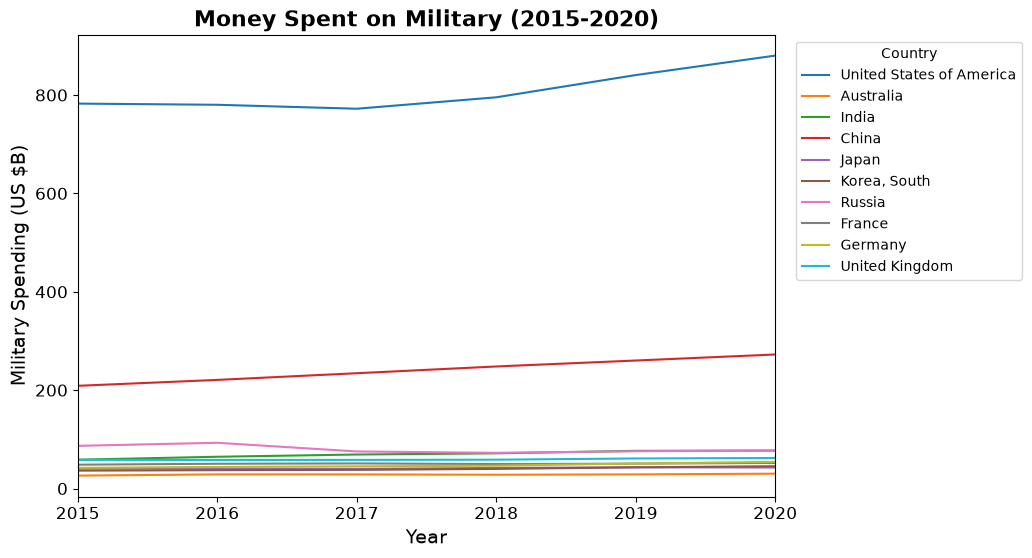

In [11]:
 plot_ms_line(military_spending)

In [12]:
#function
def plot_es_line(education_spending):
    
    #extracting unique country names from Country column
    countries = education_spending['Country Name'].unique()

    #plotting the education spending for each country
    plt.figure(figsize=(9,6)) #set a larger figure
    for country in countries:
        plt.plot(years, education_spending.loc[education_spending['Country Name'] == country, years].values.flatten(), label=country)

    #title and labels
    plt.title('Money Spent on Education (2015-2020)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Education Spending (US $B)', fontsize=14)

    #legend
    plt.legend(title='Country', loc='upper left', fontsize=10, bbox_to_anchor=(1.02, 1), ncol=1)

    #x-axis labels and font
    plt.xticks(years, fontsize=12)

    #y-axis font
    plt.yticks(fontsize=12)

    #removes space
    plt.margins(x=0)

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('educationspending_line.png', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

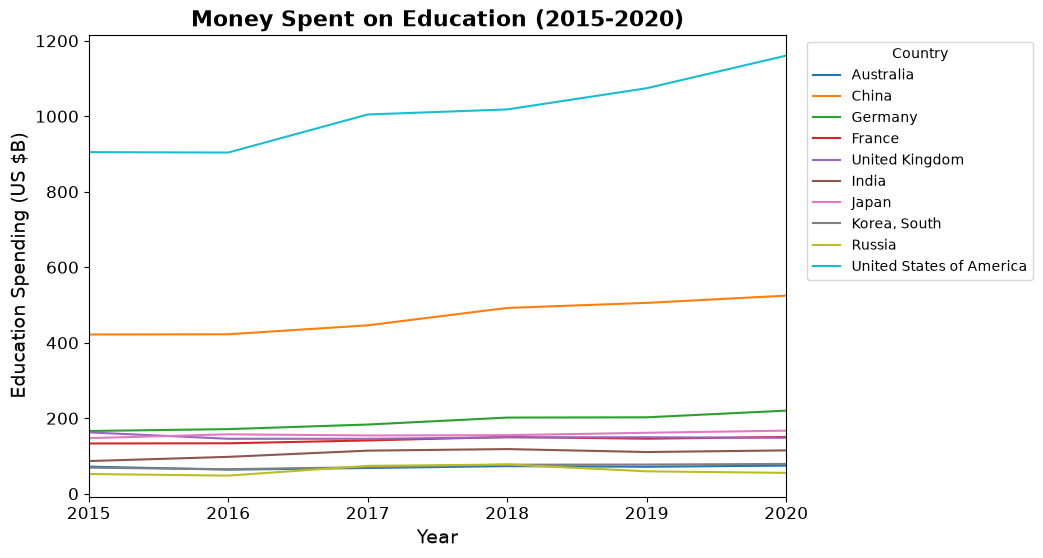

In [13]:
plot_es_line(education_spending)

In [14]:
#function
def plot_hs_line(healthcare_spending):
    #extracting unique country names from Country column
    countries = healthcare_spending['Country Name'].unique()

    #plotting the healthcare spending for each country
    plt.figure(figsize=(9,6)) #set a larger figure
    for country in countries:
        plt.plot(years, healthcare_spending.loc[healthcare_spending['Country Name'] == country, years].values.flatten(), label=country)

    #title and labels
    plt.title('Money Spent on Healthcare (2015-2020)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Healthcare Spending (US $B)', fontsize=14)

    #legend
    plt.legend(title='Country', loc='upper left', fontsize=10, bbox_to_anchor=(1.02, 1), ncol=1)

    #x-axis labels and font
    plt.xticks(years, fontsize=12)

    #y-axis font
    plt.yticks(fontsize=12)

    #removes space
    plt.margins(x=0)

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('healthcarespending_line.png', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

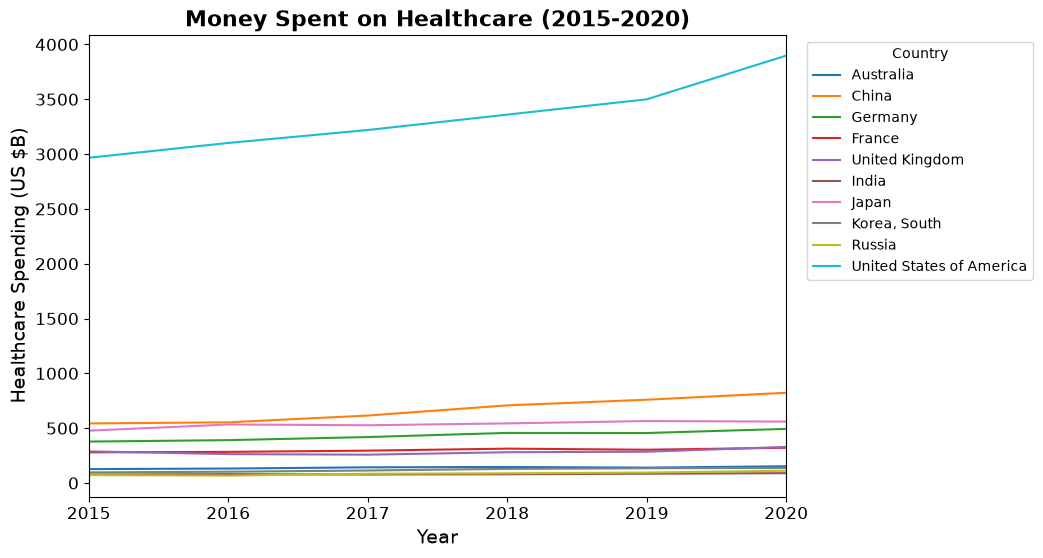

In [15]:
plot_hs_line(healthcare_spending)

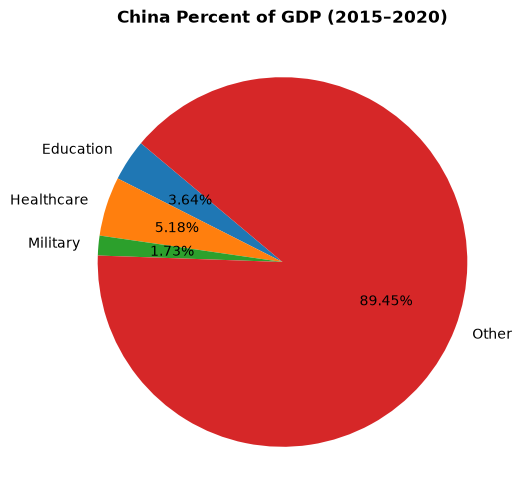

In [16]:
#Makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'China'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('China Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('China_Pie.png', dpi=300)

#plot
plt.show()


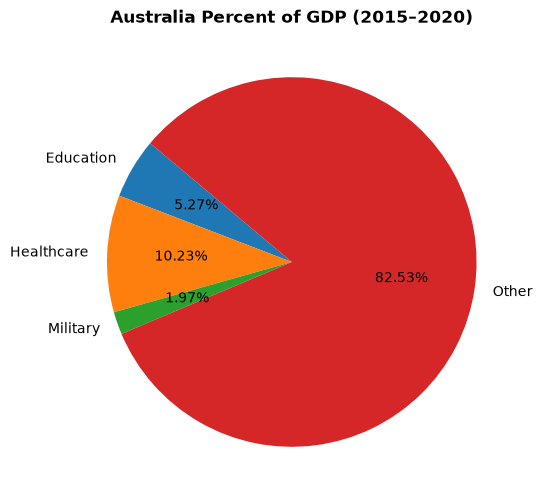

In [17]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'Australia'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('Australia Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('Australia_Pie.png', dpi=300)

#plot
plt.show()

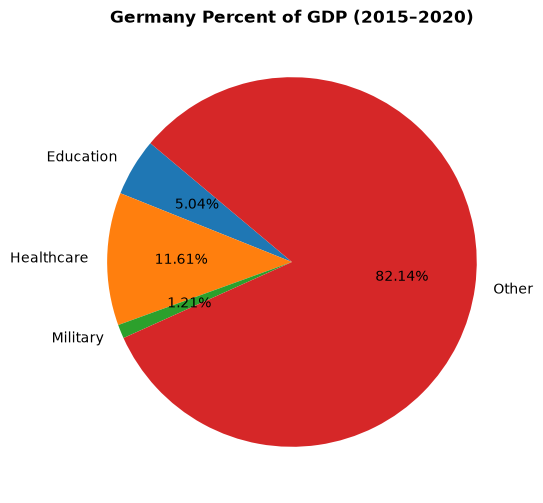

In [18]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'Germany'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('Germany Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('Germany_Pie.png', dpi=300)

#plot
plt.show()

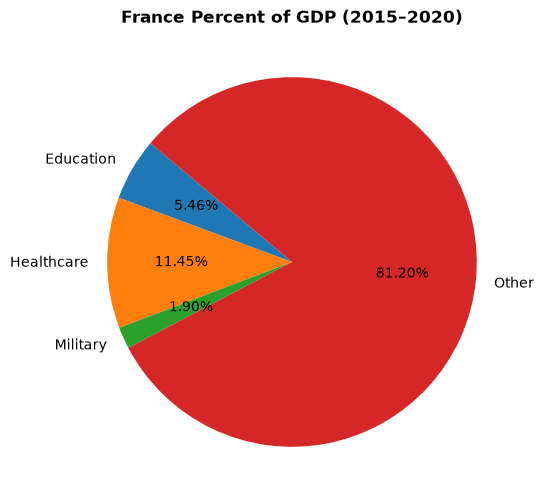

In [19]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'France'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('France Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('France_Pie.png', dpi=300)

#plot
plt.show()

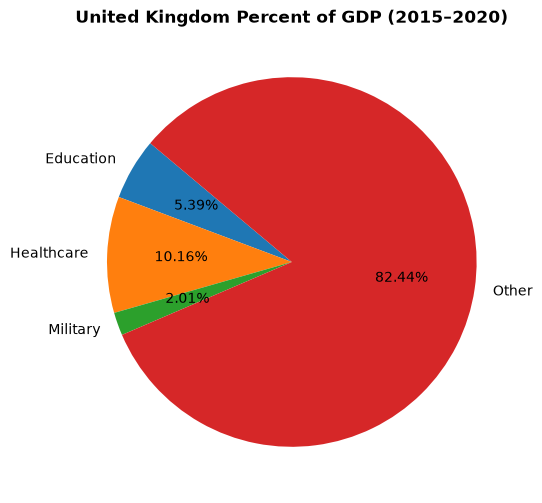

In [20]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'United Kingdom'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('United Kingdom Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('United_Kingdom_Pie.png', dpi=300)

#plot
plt.show()

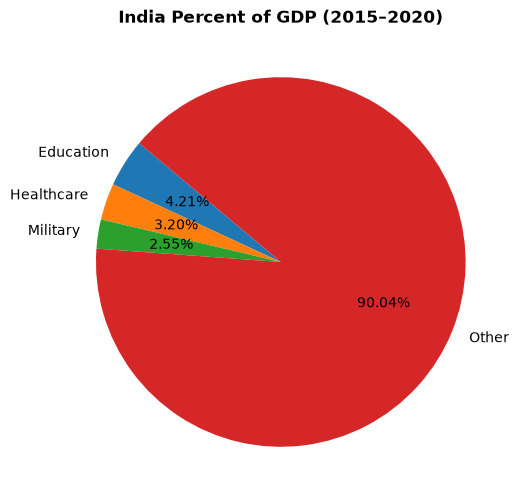

In [21]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'India'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('India Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('India_Pie.png', dpi=300)

#save figure
plt.show()

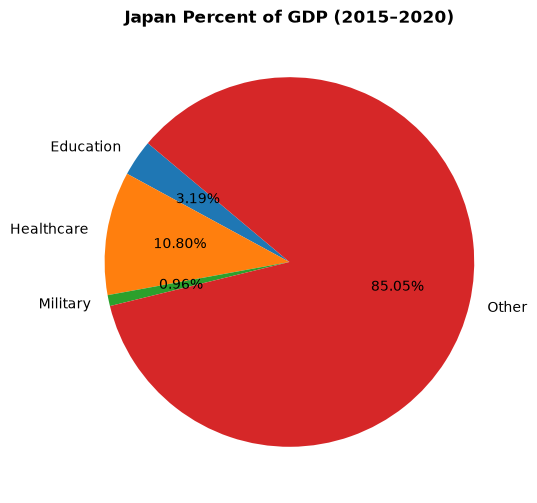

In [22]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#country of choice
country = 'Japan'

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == country, years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == country, years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == country, years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('Japan Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('Japan_Pie.png', dpi=300)

#plot
plt.show()

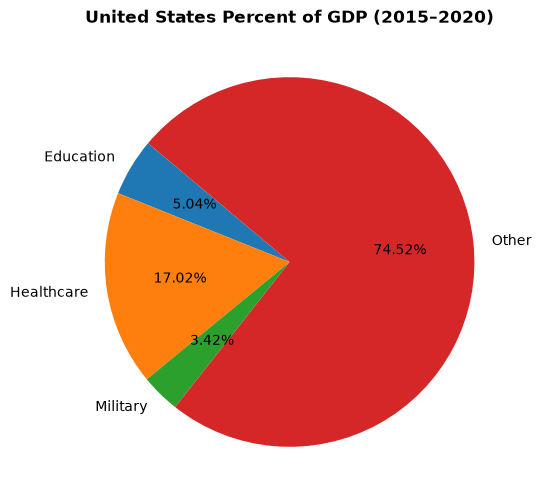

In [23]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == 'United States', years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == 'United States', years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == 'United States of America', years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('United States Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('United_States_Pie.png', dpi=300)

#plot
plt.show()

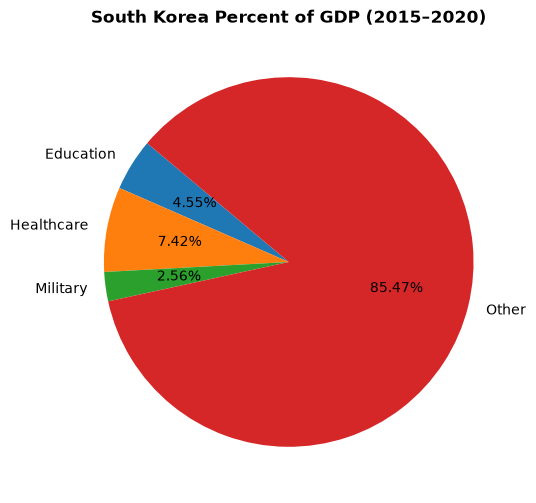

In [24]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == 'Korea, Rep.', years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == 'Korea, Rep.', years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == 'Korea, South', years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('South Korea Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('South_Korea_Pie.png', dpi=300)

#plot
plt.show()

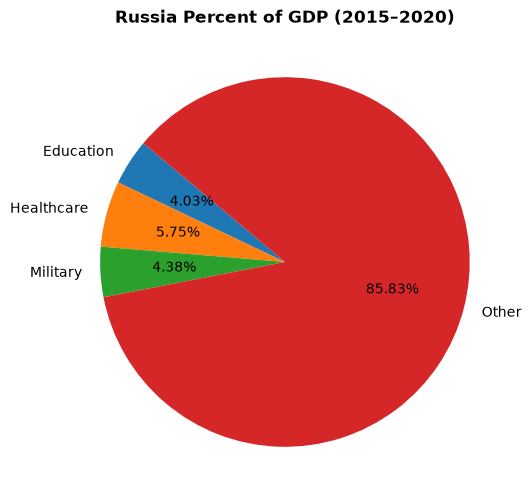

In [25]:
#makes columns strings
eg.columns = eg.columns.map(str)
hg.columns = hg.columns.map(str)
mg.columns = mg.columns.map(str)

#calculate average percent of gdp for each category
epg = eg.loc[eg['Country Name'] == 'Russian Federation', years].mean(axis=1).values[0]
hpg = hg.loc[hg['Country Name'] == 'Russian Federation', years].mean(axis=1).values[0]
mpg = mg.loc[mg['Country'] == 'Russia', years].mean(axis=1).values[0] * 100 

#calculate other
other = 100 - (epg + hpg + mpg)

#data and labels
pieces = [epg, hpg, mpg, other]
categories = ['Education', 'Healthcare', 'Military', 'Other']

#figure size
plt.figure(figsize=(6,6))

#pie chart
plt.pie(pieces, labels=categories, autopct='%1.2f%%', startangle=140)

#title
plt.title('Russia Percent of GDP (2015–2020)', fontweight = 'bold')

#save figure
plt.savefig('Russia_Pie.png', dpi=300)

#plot
plt.show()

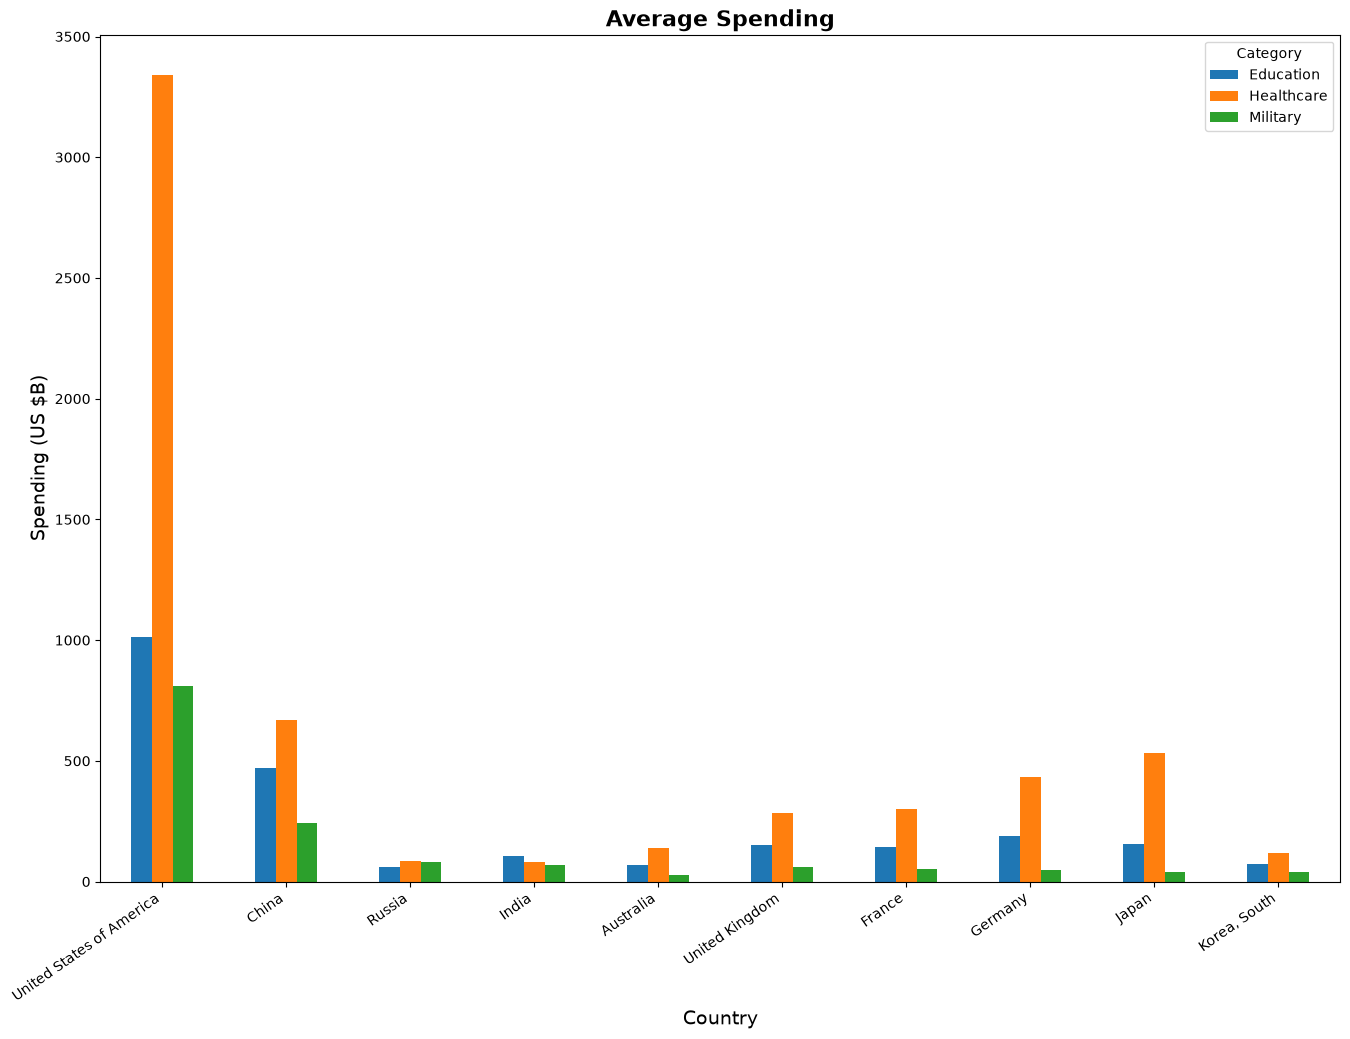

In [26]:
#makes columns strings
education_spending.columns = education_spending.columns.map(str)
healthcare_spending.columns = healthcare_spending.columns.map(str)
military_spending.columns = military_spending.columns.map(str)

#calculate spending averages in billions
average_education_spending = education_spending.set_index('Country Name')[years].mean(axis=1)
average_healthcare_spending = healthcare_spending.set_index('Country Name')[years].mean(axis=1)
average_military_spending = military_spending.set_index('Country')[years].div(1e3).mean(axis=1)

#Filter for top countries
average_education_spending = average_education_spending.loc[top_countries]
average_healthcare_spending = average_healthcare_spending.loc[top_countries]
average_military_spending = average_military_spending.loc[top_countries]

#make dataframe
averages_table = pd.DataFrame({
    'Education': average_education_spending,
    'Healthcare': average_healthcare_spending,
    'Military': average_military_spending})

#bar chart
averages_table.plot(kind='bar', figsize=(16, 11))

#title
plt.title('Average Spending', fontsize=16, fontweight='bold')

#y-axis
plt.ylabel('Spending (US $B)', fontsize=14)

#x-axis
plt.xlabel('Country', fontsize=14)

#rotate country names
plt.xticks(rotation=35, ha='right')

#legend
plt.legend(title='Category')

#save figure
plt.savefig('averagespending_bar.png', dpi=300)

#plot
plt.show()

In [27]:
averages_table

,Education,Healthcare,Military
United States of America,1011.12,3340.89,808.54
China,468.86,667.17,240.83
Russia,61.06,86.59,80.15
India,107.01,81.57,69.60
Australia,70.49,140.21,28.44
United Kingdom,150.16,284.32,59.41
France,142.41,299.54,50.39
Germany,190.86,432.41,47.07
Japan,157.14,534.47,41.36
"Korea, South",72.92,119.12,40.01


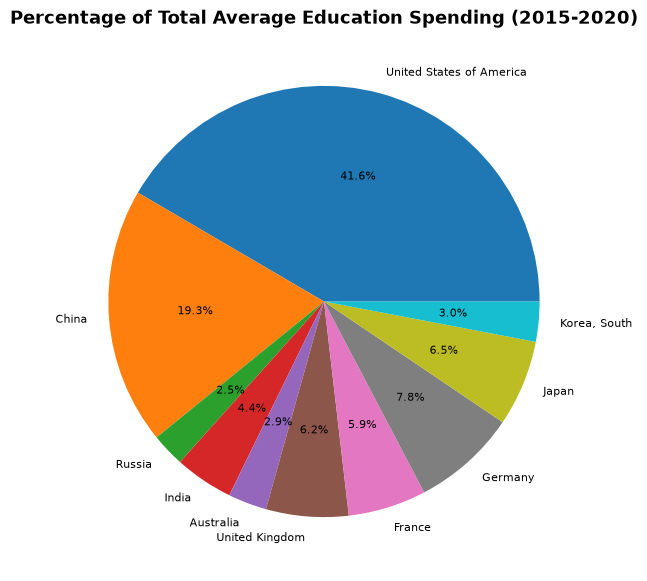

In [28]:
#grab list of countries
countries = averages_table.index 

#Education Pie
plt.figure(figsize=(8, 7))
plt.pie(averages_table['Education'], labels=countries, autopct='%1.1f%%', textprops={'fontsize': 8})
plt.title('Percentage of Total Average Education Spending (2015-2020)', fontsize=13, fontweight='bold')  
plt.savefig('education_pie.png', dpi=300)
plt.show()

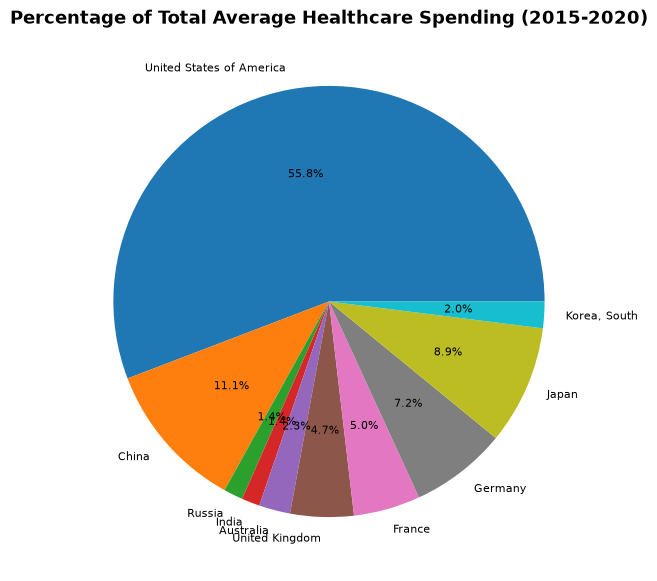

In [29]:
#Healthcare Pie
plt.figure(figsize=(8, 7))
plt.pie(averages_table['Healthcare'], labels=countries, autopct='%1.1f%%', textprops={'fontsize': 8})
plt.title('Percentage of Total Average Healthcare Spending (2015-2020)', fontsize=13, fontweight='bold')  
plt.savefig('healthcare_pie.png', dpi=300)
plt.show()

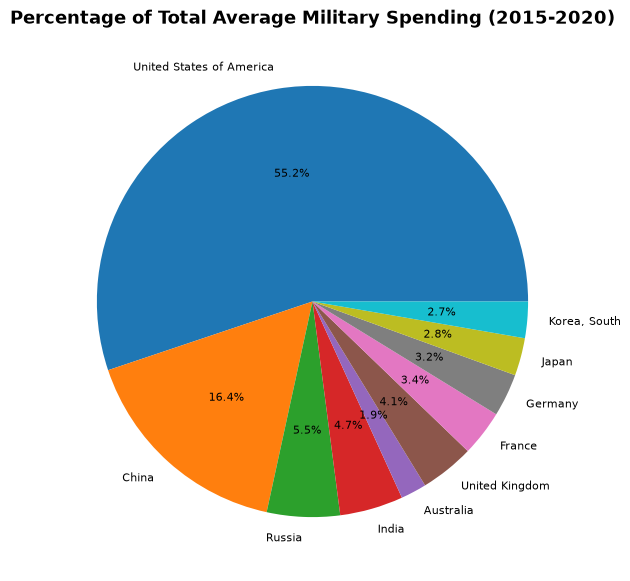

In [30]:
#Military Pie
plt.figure(figsize=(8, 7))
plt.pie(averages_table['Military'], labels=countries, autopct='%1.1f%%', textprops={'fontsize': 8})
plt.title('Percentage of Total Average Military Spending (2015-2020)', fontsize=13, fontweight='bold')  
plt.savefig('military_pie.png', dpi=300)
plt.show()

In [31]:
#filter rows for top countries 
mpercapita = mpc[mpc['Country'].isin(top_countries)]

#filter columns for the specified years
mpercapita = mpercapita[['Country'] + list(range(2015, 2021)) ]

#Shows Table
mpercapita

,Country,2015,2016,2017,2018,2019,2020
71,United States of America,1952.60,1955.49,1961.10,2054.83,2196.53,2317.06
86,Australia,1009.50,1090.38,1126.11,1074.50,1028.49,1063.53
93,India,38.78,42.31,47.67,48.40,51.67,52.23
98,China,141.02,141.62,149.22,164.09,169.03,181.04
99,Japan,330.89,365.93,355.74,384.42,403.67,410.37
101,"Korea, South",717.16,718.87,760.42,833.45,851.33,889.52
150,Russia,459.13,477.20,460.03,422.99,447.38,423.80
159,France,715.37,740.29,766.96,799.80,778.24,818.04
160,Germany,465.07,484.75,511.73,560.91,590.27,639.86
173,United Kingdom,919.76,812.24,788.24,840.44,847.09,869.87


In [32]:
#copy of data
hpercapita = hpc.copy()

#rename column
hpercapita = hpercapita.rename(columns={'Country Name': 'Country'})

#replace country names
hpercapita['Country'] = hpercapita['Country'].replace(new_names)

#filter rows for top countries 
hpercapita = hpercapita[hpercapita['Country'].isin(top_countries)]

#filter columns for the specified years
hpercapita = hpercapita[['Country'] + years]

#Shows Table
hpercapita

,Country,2015,2016,2017,2018,2019,2020
13,Australia,5322.97,5453.92,5813.61,5857.29,5545.91,5958.77
40,China,393.78,398.79,440.59,504.80,539.62,583.43
55,Germany,4627.36,4746.87,5070.20,5511.21,5486.99,5936.25
77,France,4201.78,4256.77,4410.60,4666.98,4504.48,4755.44
81,United Kingdom,4433.86,4017.34,3910.81,4226.21,4268.68,4906.24
109,India,58.00,60.00,57.00,58.00,61.00,64.00
119,Japan,3755.00,4200.00,4148.00,4288.00,4463.00,4436.00
126,"Korea, South",1894.35,2008.10,2220.56,2501.14,2605.99,2648.22
202,Russia,499.00,465.00,580.00,609.00,654.00,771.00
251,United States of America,9248.93,9599.89,9902.82,10280.53,10658.40,11758.42


In [33]:
#copy of data
epercapita = education_spending.copy()

#rename column
epercapita = epercapita.rename(columns={'Country Name': 'Country'})

#replace country names
epercapita['Country'] = epercapita['Country'].replace(new_names)

#filter rows for top countries 
epercapita = epercapita[epercapita['Country'].isin(top_countries)]

#filter columns for the specified years
epercapita = epercapita[['Country'] + years]

#solve for data
epercapita[years] = (epercapita[years] * 1e9) / pop[years]

#Shows Table
epercapita 

,Country,2015,2016,2017,2018,2019,2020
13,Australia,3015.97,2637.53,2769.59,2930.92,2822.46,2904.70
40,China,305.75,304.43,319.53,350.90,359.20,371.90
55,Germany,2034.84,2078.98,2217.98,2433.64,2436.80,2647.39
77,France,2000.28,2003.01,2109.07,2239.55,2163.63,2224.00
81,United Kingdom,2497.14,2219.40,2203.57,2245.76,2239.23,2210.17
109,India,65.18,72.69,83.97,86.06,79.55,81.87
119,Japan,1157.97,1238.92,1215.73,1223.47,1275.26,1323.86
126,"Korea, South",1353.53,1268.75,1367.76,1491.10,1494.52,1523.17
202,Russia,361.42,331.09,508.13,533.25,408.49,380.50
251,United States of America,2821.65,2797.79,3090.24,3115.11,3271.89,3501.04


In [34]:
#rename column
gdpc = gdpc.rename(columns={'Country Name': 'Country'})

#replace old country names with new names
gdpc['Country'] = gdpc['Country'].replace(new_names)

In [35]:
#filter rows for top countries 
gpercapita = gdpc[gdpc['Country'].isin(top_countries)]

#filter columns for the specified years
gpercapita = gpercapita[['Country']+ years]

#Shows Table
gpercapita

,Country,2015,2016,2017,2018,2019,2020
13,Australia,56739.03,49888.04,53901.71,57196.42,54972.70,51791.54
40,China,8016.45,8094.39,8817.05,9905.41,10143.86,10408.72
55,Germany,41911.01,42961.04,45526.60,48874.86,47623.87,47379.77
77,France,36702.43,37024.22,38687.16,41418.18,40408.28,39169.86
81,United Kingdom,44964.39,40985.24,40572.12,43203.81,42662.54,40201.68
109,India,1584.00,1707.51,1950.10,1966.25,2041.43,1907.04
119,Japan,34960.64,39375.47,38834.05,39751.13,40415.96,40040.77
126,"Korea, South",28737.44,29280.44,31600.74,33447.16,31902.42,31721.30
202,Russia,9277.71,8663.16,10658.91,11211.89,11447.70,10108.33
251,United States of America,57040.21,58206.61,60322.26,63201.05,65604.68,64411.37


In [36]:
#function
def plot_militarypercapita(gpercapita, mpercapita):
    
    #Melts country and year data for gdp per capita and military per capita
    gdp_per_capita = gpercapita.melt(id_vars=['Country'], var_name='Year', value_name='gdp')
    military_per_capita = mpercapita.melt(id_vars=['Country'], var_name='Year', value_name='military')

    #make columns strings
    gdp_per_capita['Year'] = gdp_per_capita['Year'].astype(str)
    military_per_capita['Year'] = military_per_capita['Year'].astype(str)

    #Merge into one data set
    percapita = pd.merge(gdp_per_capita, military_per_capita, on=['Country', 'Year'])

    #Create scatterplot with merged data
    plt.figure(figsize=(9, 6))
    
    #Loop through countries plotting them all
    for country in percapita['Country'].unique():
        country_data = percapita[percapita['Country'] == country]
        plt.scatter(country_data['gdp'], country_data['military'], label=country)

    #Title and Labels
    plt.title('Military Spending Per Capita vs. GDP Per Capita (2015-2020)', fontsize=16, fontweight='bold')
    plt.xlabel('GDP Per Capita', fontsize=14)
    plt.ylabel('Military Spending Per Capita', fontsize=14)
   
    #Legend
    plt.legend(title='Country', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('military_scatterplot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

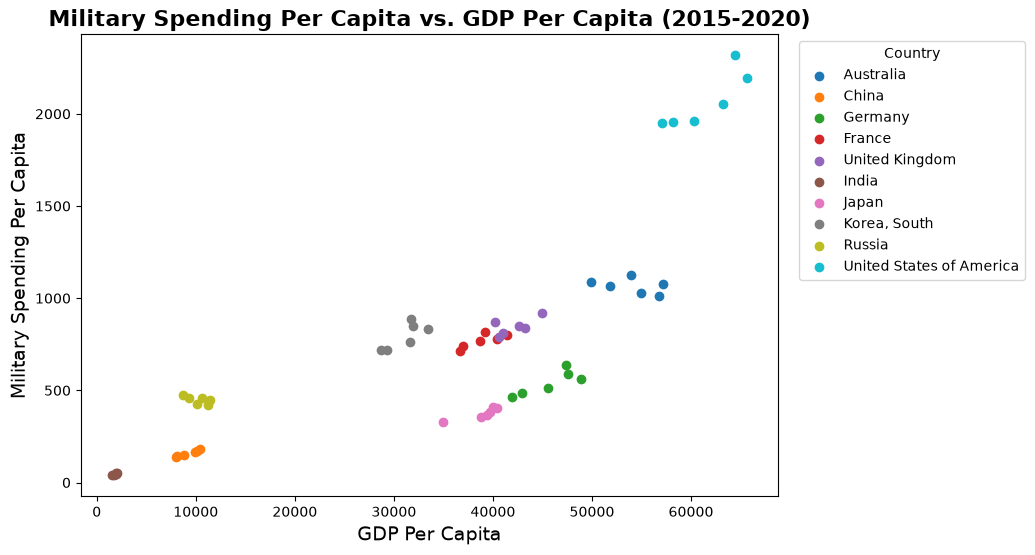

In [37]:
plot_militarypercapita(gpercapita, mpercapita)

In [38]:
#function
def plot_healthcarepercapita(gpercapita, hpercapita):
    
    #Melts country and year data for gdp per capita and healthcare per capita
    gdp_per_capita = gpercapita.melt(id_vars=['Country'], var_name='Year', value_name='gdp')
    healthcare_per_capita = hpercapita.melt(id_vars=['Country'], var_name='Year', value_name='healthcare')

    #make columns strings
    gdp_per_capita['Year'] = gdp_per_capita['Year'].astype(str)
    healthcare_per_capita['Year'] = healthcare_per_capita['Year'].astype(str)

    #Merge into one data set
    percapita = pd.merge(gdp_per_capita, healthcare_per_capita, on=['Country', 'Year'])

    #Create scatterplot with merged data
    plt.figure(figsize=(9, 6))
    
    #Loop through countries plotting them all
    for country in percapita['Country'].unique():
        country_data = percapita[percapita['Country'] == country]
        plt.scatter(country_data['gdp'], country_data['healthcare'], label=country)

    #Title and Labels
    plt.title('Healthcare Spending Per Capita vs. GDP Per Capita (2015-2020)', fontsize=16, fontweight='bold')
    plt.xlabel('GDP Per Capita', fontsize=14)
    plt.ylabel('Healthcare Spending Per Capita', fontsize=14)
   
    #Legend
    plt.legend(title='Country', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('healthcare_scatterplot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

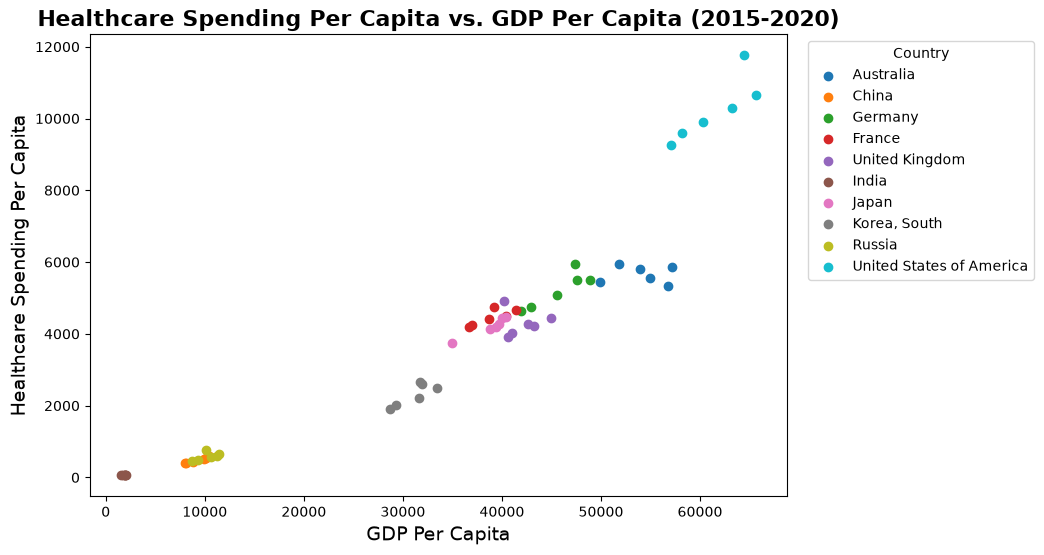

In [39]:
plot_healthcarepercapita(gpercapita, hpercapita)

In [40]:
#function
def plot_educationpercapita(gpercapita, epercapita):
    
    #Melts country and year data for gdp per capita and education per capita
    gdp_per_capita = gpercapita.melt(id_vars=['Country'], var_name='Year', value_name='gdp')
    education_per_capita = epercapita.melt(id_vars=['Country'], var_name='Year', value_name='education')

    #makes columns strings
    gdp_per_capita['Year'] = gdp_per_capita['Year'].astype(str)
    education_per_capita['Year'] = education_per_capita['Year'].astype(str)

    #Merge into one data set
    percapita = pd.merge(gdp_per_capita, education_per_capita, on=['Country', 'Year'])

    #Create scatterplot with merged data
    plt.figure(figsize=(9, 6))
    
    #Loop through countries plotting them all
    for country in percapita['Country'].unique():
        country_data = percapita[percapita['Country'] == country]
        plt.scatter(country_data['gdp'], country_data['education'], label=country)

    #Title and Labels
    plt.title('Education Spending Per Capita vs. GDP Per Capita (2015-2020)', fontsize=16, fontweight='bold')
    plt.xlabel('GDP Per Capita', fontsize=14)
    plt.ylabel('Education Spending Per Capita', fontsize=14)
   
    #Legend
    plt.legend(title='Country', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('education_scatterplot.png', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

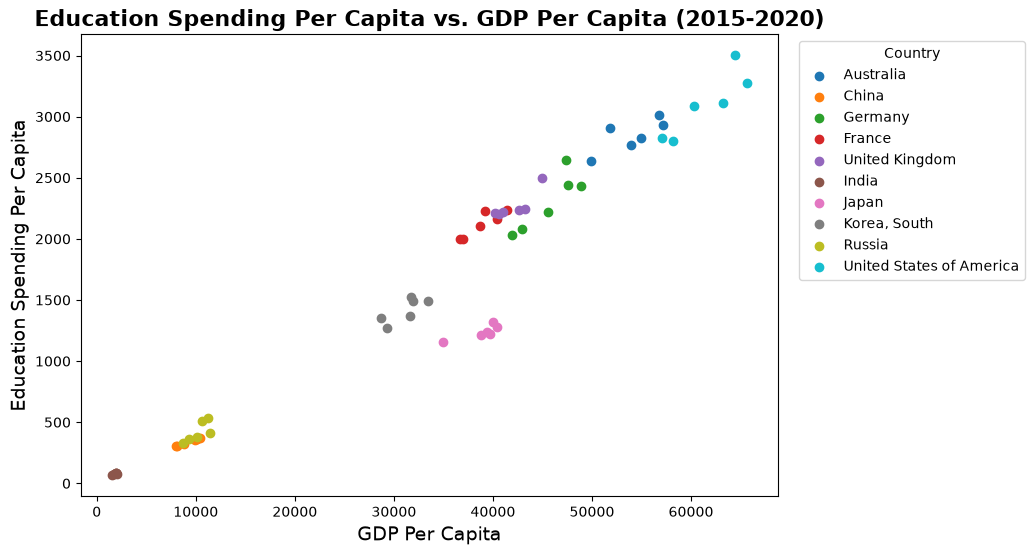

In [41]:
plot_educationpercapita(gpercapita, epercapita)

In [42]:
#Makes years into integers
healthcare_spending.columns = [int(year) if year.isdigit() else year for year in healthcare_spending.columns]

#Copy of data from 2015 to 2020
healthcare_percent_growth = healthcare_spending[['Country Name', 2015, 2020]].copy()

#Removes countries with missing data in 2015 stopping any errors
healthcare_percent_growth = healthcare_percent_growth[healthcare_percent_growth[2015] > 0]

#Growth Calculations as a percentage
healthcare_percent_growth['% Growth'] = ((healthcare_percent_growth[2020] - healthcare_percent_growth[2015]) / healthcare_percent_growth[2015]) * 100

#Top 10 countries
growth_percent_healthcare = healthcare_percent_growth[healthcare_percent_growth['Country Name'].isin(top_countries)][['Country Name', '% Growth']]

In [43]:
growth_percent_healthcare

,Country Name,% Growth
13,Australia,20.56
40,China,51.52
55,Germany,30.60
77,France,14.97
81,United Kingdom,13.99
109,India,16.54
119,Japan,17.32
126,"Korea, South",42.05
202,Russia,55.15
251,United States of America,31.41


In [44]:
#Makes years into integers
education_spending.columns = [int(year) if year.isdigit() else year for year in education_spending.columns]

#Copy of data from 2015 to 2020
education_percent_growth = education_spending[['Country Name', 2015, 2020]].copy()

#Removes countries with missing data in 2015 stopping any errors
education_percent_growth = education_percent_growth[education_percent_growth[2015] > 0]

#Growth Calculations as a percentage
education_percent_growth['% Growth'] = ((education_percent_growth[2020] - education_percent_growth[2015]) / education_percent_growth[2015]) * 100

#Top 10 countries
growth_percent_education = education_percent_growth[education_percent_growth['Country Name'].isin(top_countries)][['Country Name', '% Growth']]

In [45]:
growth_percent_education

,Country Name,% Growth
13,Australia,3.72
40,China,24.39
55,Germany,32.45
77,France,12.94
81,United Kingdom,-8.82
109,India,32.66
119,Japan,13.53
126,"Korea, South",14.34
202,Russia,5.72
251,United States of America,28.25


In [46]:
#Copy of data from 2015 to 2020
healthcare_total_growth = healthcare_spending[['Country Name', 2015, 2020]].copy()

#Growth Calculations as raw number
healthcare_total_growth['# Growth'] = healthcare_total_growth[2020] - healthcare_total_growth[2015]

#Top 10 countries
fixed_growth_healthcare = healthcare_total_growth[healthcare_total_growth['Country Name'].isin(top_countries)][['Country Name', '# Growth']]

In [47]:
fixed_growth_healthcare

,Country Name,# Growth
13,Australia,26.07
40,China,279.92
55,Germany,115.67
77,France,41.85
81,United Kingdom,40.40
109,India,12.74
119,Japan,82.68
126,"Korea, South",40.63
202,Russia,39.81
251,United States of America,931.74


In [48]:
#Copy of data from 2015 to 2020
education_total_growth = education_spending[['Country Name', 2015, 2020]].copy()

#Growth Calculations as raw number
education_total_growth['# Growth'] = education_total_growth[2020] - education_total_growth[2015]

#Top 10 countries
fixed_growth_education = education_total_growth[education_total_growth['Country Name'].isin(top_countries)][['Country Name', '# Growth']]

In [49]:
fixed_growth_education

,Country Name,# Growth
13,Australia,2.68
40,China,102.90
55,Germany,53.94
77,France,17.23
81,United Kingdom,-14.34
109,India,28.27
119,Japan,19.93
126,"Korea, South",9.90
202,Russia,2.99
251,United States of America,255.68


In [50]:
#function
def healthcare_spending_growth_percent(growth_percent_healthcare):

    #Creates bar chart
    plt.figure(figsize=(9,4)) #set a larger figure

    #Add growth percent data and countries
    plt.bar(growth_percent_healthcare['Country Name'], growth_percent_healthcare['% Growth'])

    #title and labels
    plt.title('Top Healthcare Spenders in Percentage Growth', fontsize=16, fontweight='bold')
    plt.xlabel('Country', fontsize=14)
    plt.ylabel('Percent Growth', fontsize=14)

    #rotate labels
    plt.xticks(rotation=35, ha='right')

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('healthcaregrowthpercent_bar', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

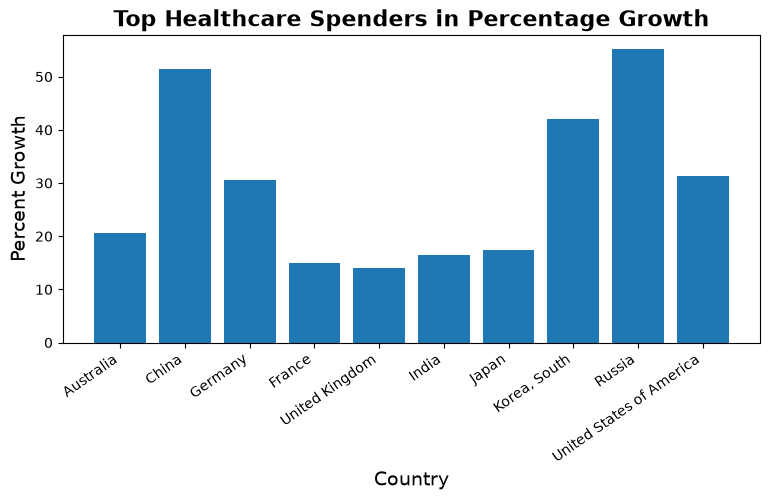

In [51]:
healthcare_spending_growth_percent(growth_percent_healthcare)

In [52]:
#function
def education_spending_growth_percent(growth_percent_education):

    #Creates bar chart
    plt.figure(figsize=(9,4)) #set a larger figure

    #Add growth percent data and countries
    plt.bar(growth_percent_education['Country Name'], growth_percent_education['% Growth'])

    #title and labels
    plt.title('Top Education Spenders in Percentage Growth', fontsize=16, fontweight='bold')
    plt.xlabel('Country', fontsize=14)
    plt.ylabel('Percent Growth', fontsize=14)

    #turns x-axis labels so they fit under the graph properly
    plt.xticks(rotation=35, ha='right')

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('educationgrowthpercent_bar', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

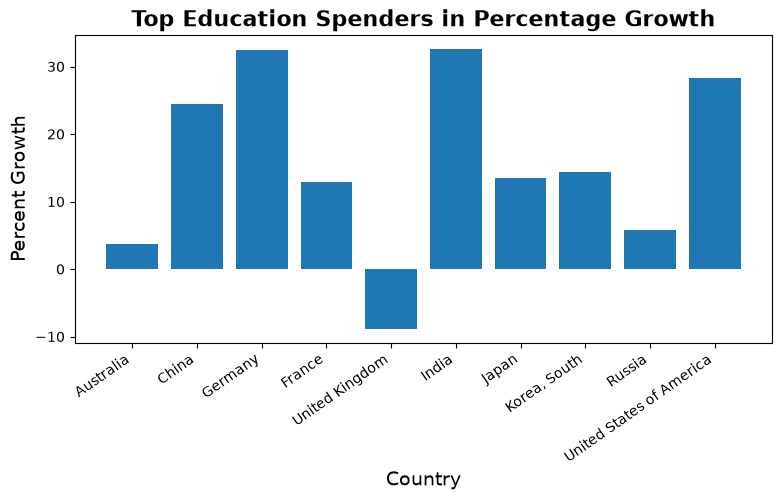

In [53]:
education_spending_growth_percent(growth_percent_education)

In [54]:
#function
def healthcare_spending_growth_fixed(fixed_growth_healthcare):

    #Creates bar chart
    plt.figure(figsize=(9,4)) #set a larger figure

    #Add fixed growth data and countries
    plt.bar(fixed_growth_healthcare['Country Name'], fixed_growth_healthcare['# Growth'])

    #title and labels
    plt.title('Top Healthcare Spenders in Fixed Growth (US $B)', fontsize=16, fontweight='bold')
    plt.xlabel('Country Name', fontsize=14)
    plt.ylabel('Fixed Growth (US $B)', fontsize=14)

    #turns x-axis labels so they fit under the graph properly
    plt.xticks(rotation=35, ha='right')

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('healthcaregrowthfixed_bar', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

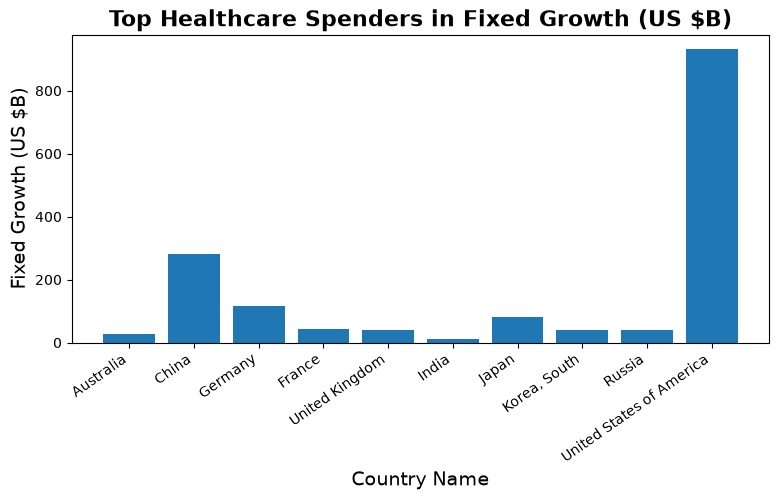

In [55]:
healthcare_spending_growth_fixed(fixed_growth_healthcare)

In [56]:
#function
def education_spending_growth_fixed(fixed_growth_education):

    #Creates bar chart
    plt.figure(figsize=(9,4)) #set a larger figure

    #Add fixed growth data and countries
    plt.bar(fixed_growth_education['Country Name'], fixed_growth_education['# Growth'])

    #title and labels
    plt.title('Top Education Spenders in Fixed Growth', fontsize=16, fontweight='bold')
    plt.xlabel('Country Name', fontsize=14)
    plt.ylabel('Fixed Growth (US $B)', fontsize=14)

    #turns x-axis labels so they fit under the graph properly
    plt.xticks(rotation=35, ha='right')

    #save the chart as a PNG file with high resolution (300 DPI)
    plt.savefig('educationgrowthfixed_bar', dpi = 300, bbox_inches='tight', pad_inches=0.2) #increase the padding
    plt.show()

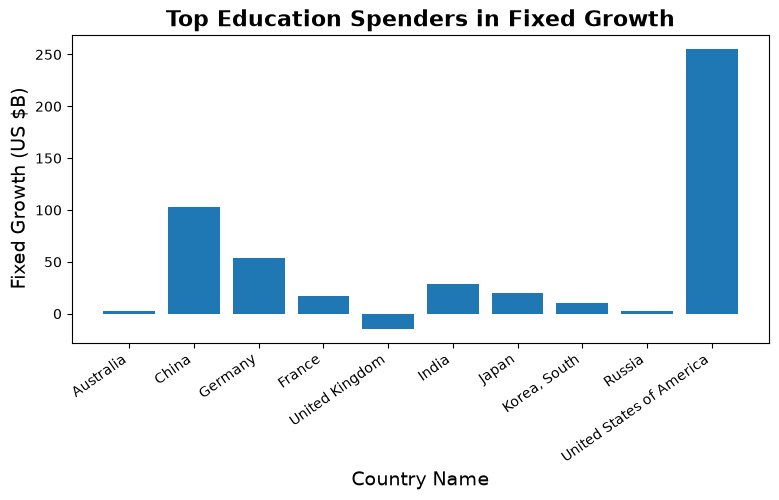

In [57]:
education_spending_growth_fixed(fixed_growth_education)